# Обучение и предсказание

Размерность данных: (1356, 45)

Диагнозы: diagnosis_code
J44.8    204
D14.3    185
U07.1    167
A15.0    163
C34.1    155
C34.3    119
J44.1    118
J15.8     91
A16.0     84
J45.9     70
Name: count, dtype: int64
Количество классов: 10
Размерность признаков: (1356, 42)
Размерность тренировочных данных: (1084, 42, 1)
Размерность тестовых данных: (272, 42, 1)


c:\Users\PC2\Desktop\Klukin\Epikriz_2\Epikriz_project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Модель создана успешно
Начало обучения модели...
Обучение завершено!
Точность на тестовой выборке: 0.6912
Выполнение предсказаний...

Отчет по классификации:
              precision    recall  f1-score   support

       A15.0       0.66      0.82      0.73        33
       A16.0       0.69      0.53      0.60        17
       C34.1       0.51      0.71      0.59        31
       C34.3       0.29      0.08      0.13        24
       D14.3       0.82      0.76      0.79        37
       J15.8       0.60      0.50      0.55        18
       J44.1       0.63      0.71      0.67        24
       J44.8       0.81      0.85      0.83        41
       J45.9       0.80      0.86      0.83        14
       U07.1       0.79      0.82      0.81        33

    accuracy                           0.69       272
   macro avg       0.66      0.66      0.65       272
weighted avg       0.67      0.69      0.67       272



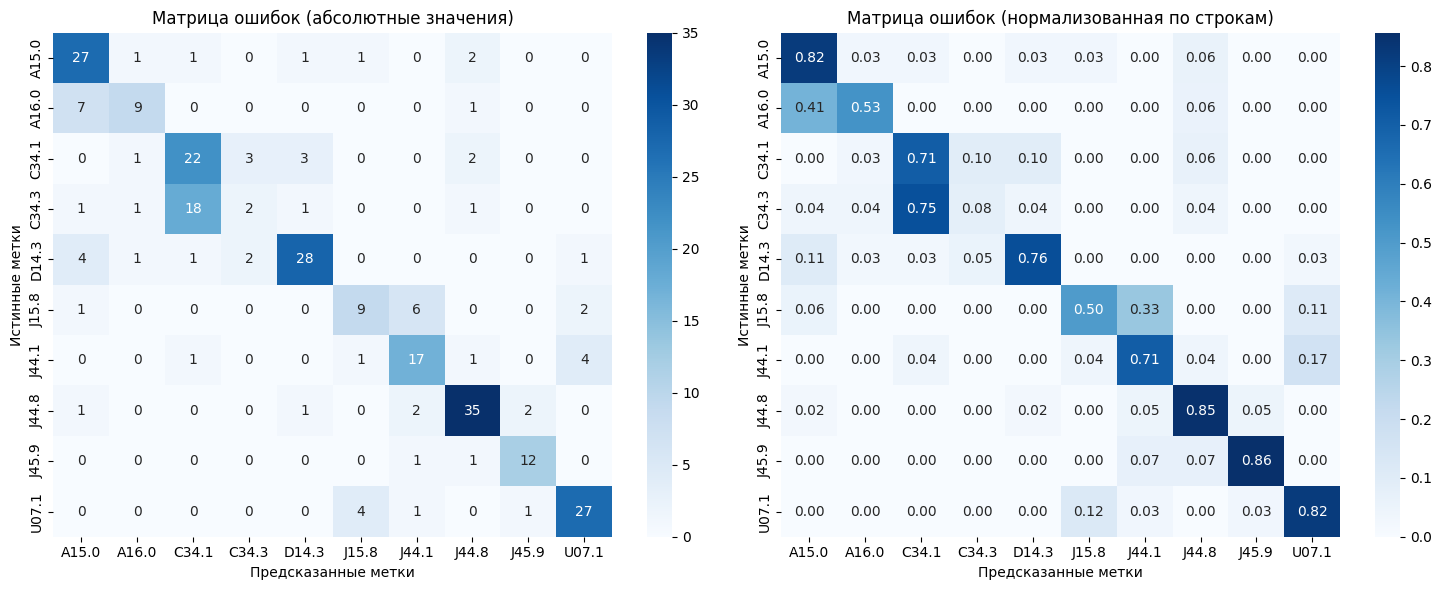


АНАЛИЗ МАТРИЦЫ ОШИБОК:

Точность по классам:
A15.0: 81.8% (27/33)
A16.0: 52.9% (9/17)
C34.1: 71.0% (22/31)
C34.3: 8.3% (2/24)
D14.3: 75.7% (28/37)
J15.8: 50.0% (9/18)
J44.1: 70.8% (17/24)
J44.8: 85.4% (35/41)
J45.9: 85.7% (12/14)
U07.1: 81.8% (27/33)

Основные ошибки классификации:
  A15.0 → A16.0: 1 случаев (3.0%)
  A15.0 → C34.1: 1 случаев (3.0%)
  A15.0 → D14.3: 1 случаев (3.0%)
  A15.0 → J15.8: 1 случаев (3.0%)
  A15.0 → J44.8: 2 случаев (6.1%)
  A16.0 → A15.0: 7 случаев (41.2%)
  A16.0 → J44.8: 1 случаев (5.9%)
  C34.1 → A16.0: 1 случаев (3.2%)
  C34.1 → C34.3: 3 случаев (9.7%)
  C34.1 → D14.3: 3 случаев (9.7%)
  C34.1 → J44.8: 2 случаев (6.5%)
  C34.3 → A15.0: 1 случаев (4.2%)
  C34.3 → A16.0: 1 случаев (4.2%)
  C34.3 → C34.1: 18 случаев (75.0%)
  C34.3 → D14.3: 1 случаев (4.2%)
  C34.3 → J44.8: 1 случаев (4.2%)
  D14.3 → A15.0: 4 случаев (10.8%)
  D14.3 → A16.0: 1 случаев (2.7%)
  D14.3 → C34.1: 1 случаев (2.7%)
  D14.3 → C34.3: 2 случаев (5.4%)
  D14.3 → U07.1: 1 случаев (2.7%

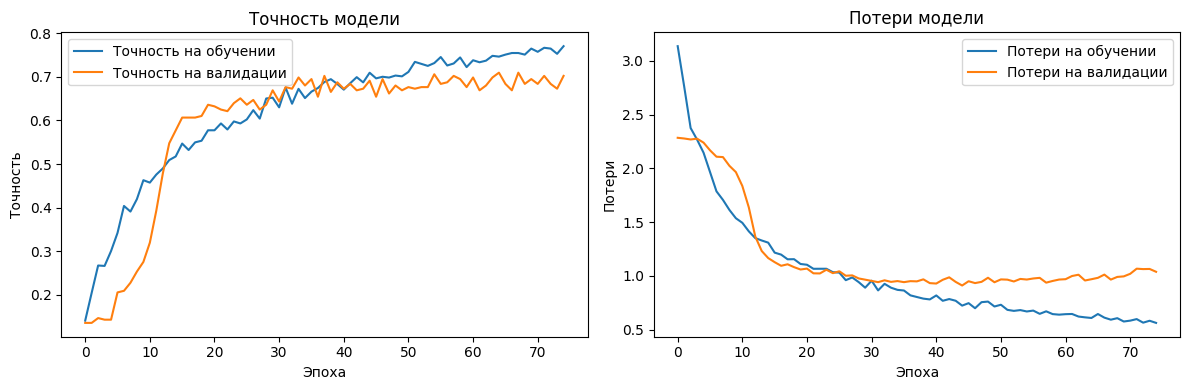

Модель и preprocessing objects сохранены!

Классы диагнозов в наборе данных:
A15.0: 0
A15.0: Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры
A16.0: Туберкулез легких при отрицательных результатах бактериологических и гистологических исследований
A16.0: 0
C34.1: Злокачественное новообразование верхней доли, бронхов или легкого
C34.1: 0
C34.3: Злокачественное новообразование нижней доли, бронхов или легкого
C34.3: 0
D14.3: Доброкачественное новообразование бронха и легкого
D14.3: 0
J15.8: 0
J15.8: Другие бактериальные пневмонии
J44.1: 0
J44.1: Хроническая обструктивная легочная болезнь с обострением неуточненная
J44.8: Другая уточненная хроническая обструктивная легочная болезнь
J44.8: 0
J45.9: Астма неуточненная
J45.9: 0
U07.1: 0
U07.1: COVID-19, вирус идентифицирован
Всего классов: 20

Статистика по классам:
----------------------------------------
J44.8: 204 записей (15.0%) - Другая уточненная хроническая обструктивная легочная болезнь
D1

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../../parsing/medical_features_analysis_10.csv')

# Просмотр структуры данных
print("Размерность данных:", df.shape)
print("\nДиагнозы:", df['diagnosis_code'].value_counts())

# Предобработка данных
df.fillna(0, inplace=True)

# Выбор признаков
exclude_columns = ['filename', 'diagnosis_code', 'diagnosis_name']
feature_columns = [col for col in df.columns if col not in exclude_columns]

X = df[feature_columns].values
y = df['diagnosis_code'].values

# Кодирование меток
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))

print(f"Количество классов: {num_classes}")
print(f"Размерность признаков: {X.shape}")

# Нормализация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Преобразование в 3D формат для CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Преобразование меток в one-hot encoding
y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

print(f"Размерность тренировочных данных: {X_train.shape}")
print(f"Размерность тестовых данных: {X_test.shape}")

# Создание модели CNN+LSTM
def create_cnn_lstm_model(input_shape, num_classes):
    model = Sequential()
    
    # CNN часть
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', 
                    input_shape=input_shape, padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    
    # LSTM часть
    model.add(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
    model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
    
    # Полносвязные слои
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    # Выходной слой
    model.add(Dense(num_classes, activation='softmax'))
    
    # Компиляция модели
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Создание модели
input_shape = (X_train.shape[1], X_train.shape[2])
model = create_cnn_lstm_model(input_shape, num_classes)

print("Модель создана успешно")

# Callbacks для обучения
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=0
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=30,
    min_lr=0.00001,
    verbose=0
)

checkpoint = ModelCheckpoint(
    'best_cnn_lstm_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

print("Начало обучения модели...")

# Обучение модели (verbose=0 для скрытия вывода эпох)
history = model.fit(
    X_train, y_train_categorical,
    batch_size=32,
    epochs=100,
    validation_data=(X_test, y_test_categorical),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=0
)

print("Обучение завершено!")

# Оценка модели
test_loss, test_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

# Предсказания
print("Выполнение предсказаний...")
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Метрики классификации
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred_classes, 
                         target_names=label_encoder.classes_))

# Создание фигуры для матриц ошибок
plt.figure(figsize=(15, 6))

# Обычная матрица ошибок (абсолютные значения)
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок (абсолютные значения)')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')

# Нормализованная матрица ошибок
plt.subplot(1, 2, 2)
cm_normalized = confusion_matrix(y_test, y_pred_classes, normalize='true')
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок (нормализованная по строкам)')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')

plt.tight_layout()
plt.show()


# Анализ матрицы ошибок
print("\nАНАЛИЗ МАТРИЦЫ ОШИБОК:")
print("=" * 50)

cm_abs = confusion_matrix(y_test, y_pred_classes)
cm_norm = confusion_matrix(y_test, y_pred_classes, normalize='true')

print("\nТочность по классам:")
for i, class_name in enumerate(label_encoder.classes_):
    accuracy = cm_norm[i, i]
    total = np.sum(cm_abs[i, :])
    correct = cm_abs[i, i]
    print(f"{class_name}: {accuracy:.1%} ({correct}/{total})")

print("\nОсновные ошибки классификации:")
error_found = False
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        if i != j and cm_abs[i, j] > 0:
            error_found = True
            true_class = label_encoder.classes_[i]
            pred_class = label_encoder.classes_[j]
            count = cm_abs[i, j]
            percentage = cm_norm[i, j]
            print(f"  {true_class} → {pred_class}: {count} случаев ({percentage:.1%})")

if not error_found:
    print("  Все предсказания верны!")

# Графики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на валидации')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.title('Потери модели')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()

# Сохранение модели и preprocessing объектов
model.save('medical_epicrisis_cnn_lstm_model.keras')

import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

print("Модель и preprocessing objects сохранены!")

# Получаем уникальные диагнозы с их названиями
diagnosis_info = df[['diagnosis_code', 'diagnosis_name']].drop_duplicates()

# Сортируем по коду диагноза для удобства чтения
diagnosis_info = diagnosis_info.sort_values('diagnosis_code').reset_index(drop=True)

print("\nКлассы диагнозов в наборе данных:")
print("=" * 60)

for idx, row in diagnosis_info.iterrows():
    code = row['diagnosis_code']
    name = row['diagnosis_name']
    
    # Если название диагноза отсутствует, указываем это
    if pd.isna(name) or name == '':
        name = "Название не указано"
    
    print(f"{code}: {name}")

print("=" * 60)
print(f"Всего классов: {len(diagnosis_info)}")

# Дополнительная статистика
print("\nСтатистика по классам:")
print("-" * 40)

diagnosis_counts = df['diagnosis_code'].value_counts()
for code, count in diagnosis_counts.items():
    name = diagnosis_info[diagnosis_info['diagnosis_code'] == code]['diagnosis_name'].iloc[0]
    if pd.isna(name) or name == '':
        name = "Название не указано"
    percentage = (count / len(df)) * 100
    print(f"{code}: {count} записей ({percentage:.1f}%) - {name}")

## Создает файл с указанием использованных библиотек

In [ ]:
!pip freeze > requirements.txt